In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from __init_py.config import dados_tratados
from sklearn.metrics import( mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from auxiliares.auxiliares import dataframe_coeficientes
from auxiliares.graficos import plot_coeficientes, plot_residuos
 
sns.set_theme(palette="bright")

RANDON_STATE = 42

In [3]:
df= pd.read_parquet(dados_tratados)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idade             442 non-null    int8   
 1   sexo              442 non-null    int8   
 2   imc               442 non-null    float32
 3   pressao_media     442 non-null    float32
 4   colesterol_total  442 non-null    int16  
 5   ldl               442 non-null    float32
 6   hdl               442 non-null    float32
 7   colesterol_hdl    442 non-null    float32
 8   triglicerides     442 non-null    float32
 9   glicose           442 non-null    int8   
 10  target            442 non-null    int16  
dtypes: float32(6), int16(2), int8(3)
memory usage: 13.5 KB


In [5]:
X = df.drop(columns="target")
y=df['target']

In [6]:
X_train, X_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDON_STATE
)
pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]
)

In [7]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [8]:
pipeline.score(X_text,y_test)

0.4526028037071228

In [9]:
pipeline.named_steps

{'scaler': StandardScaler(), 'reg': LinearRegression()}

In [10]:
pipeline['reg']

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
pipeline['reg'].coef_

array([  1.7537551, -11.51179  ,  25.607117 ,  16.828867 , -44.448883 ,
        24.64099  ,   7.676994 ,  13.13877  ,  35.161213 ,   2.3513677],
      dtype=float32)

In [12]:
pipeline['reg'].intercept_

np.float32(153.73656)

In [13]:
coefs = dataframe_coeficientes(
    pipeline['reg'].coef_,
    X.columns    
)

coefs

,coeficiente
colesterol_total,-44.448883
sexo,-11.511790
idade,1.753755
glicose,2.351368
hdl,7.676994
colesterol_hdl,13.138770
pressao_media,16.828867
ldl,24.640989
imc,25.607117
triglicerides,35.161213


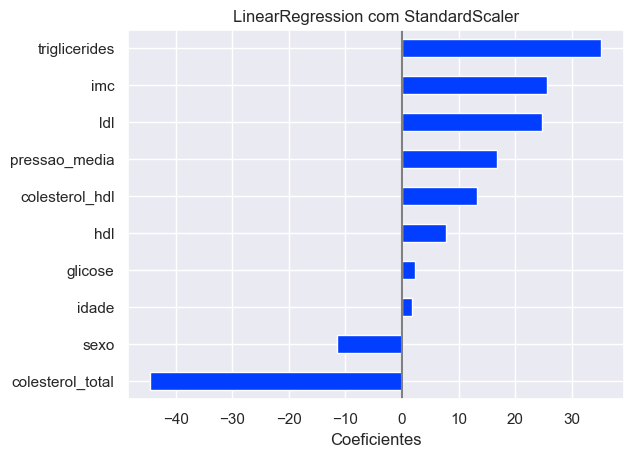

In [14]:
plot_coeficientes(coefs,"LinearRegression com StandardScaler")

In [15]:
pipeline["scaler"]

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [16]:
pipeline["scaler"].transform(X)

array([[ 0.791774  ,  1.06137   ,  1.2701278 , ..., -0.06221043,
         0.39135745, -0.40439725],
       [-0.07183776, -0.9421785 , -1.127127  , ..., -0.8354585 ,
        -1.4561756 , -1.9476649 ],
       [ 1.812406  ,  1.06137   ,  0.9048321 , ..., -0.06221043,
         0.03444803, -0.5758714 ],
       ...,
       [ 0.87028414,  1.06137   , -0.3737041 , ..., -0.2400575 ,
        -1.0070798 ,  0.28149948],
       [-1.0139596 , -0.9421785 ,  0.7906771 , ...,  0.5486555 ,
         0.90687287, -0.5758714 ],
       [-1.0139596 , -0.9421785 , -1.583747  , ..., -0.8354585 ,
        -0.11385113,  0.02428821]], shape=(442, 10), dtype=float32)

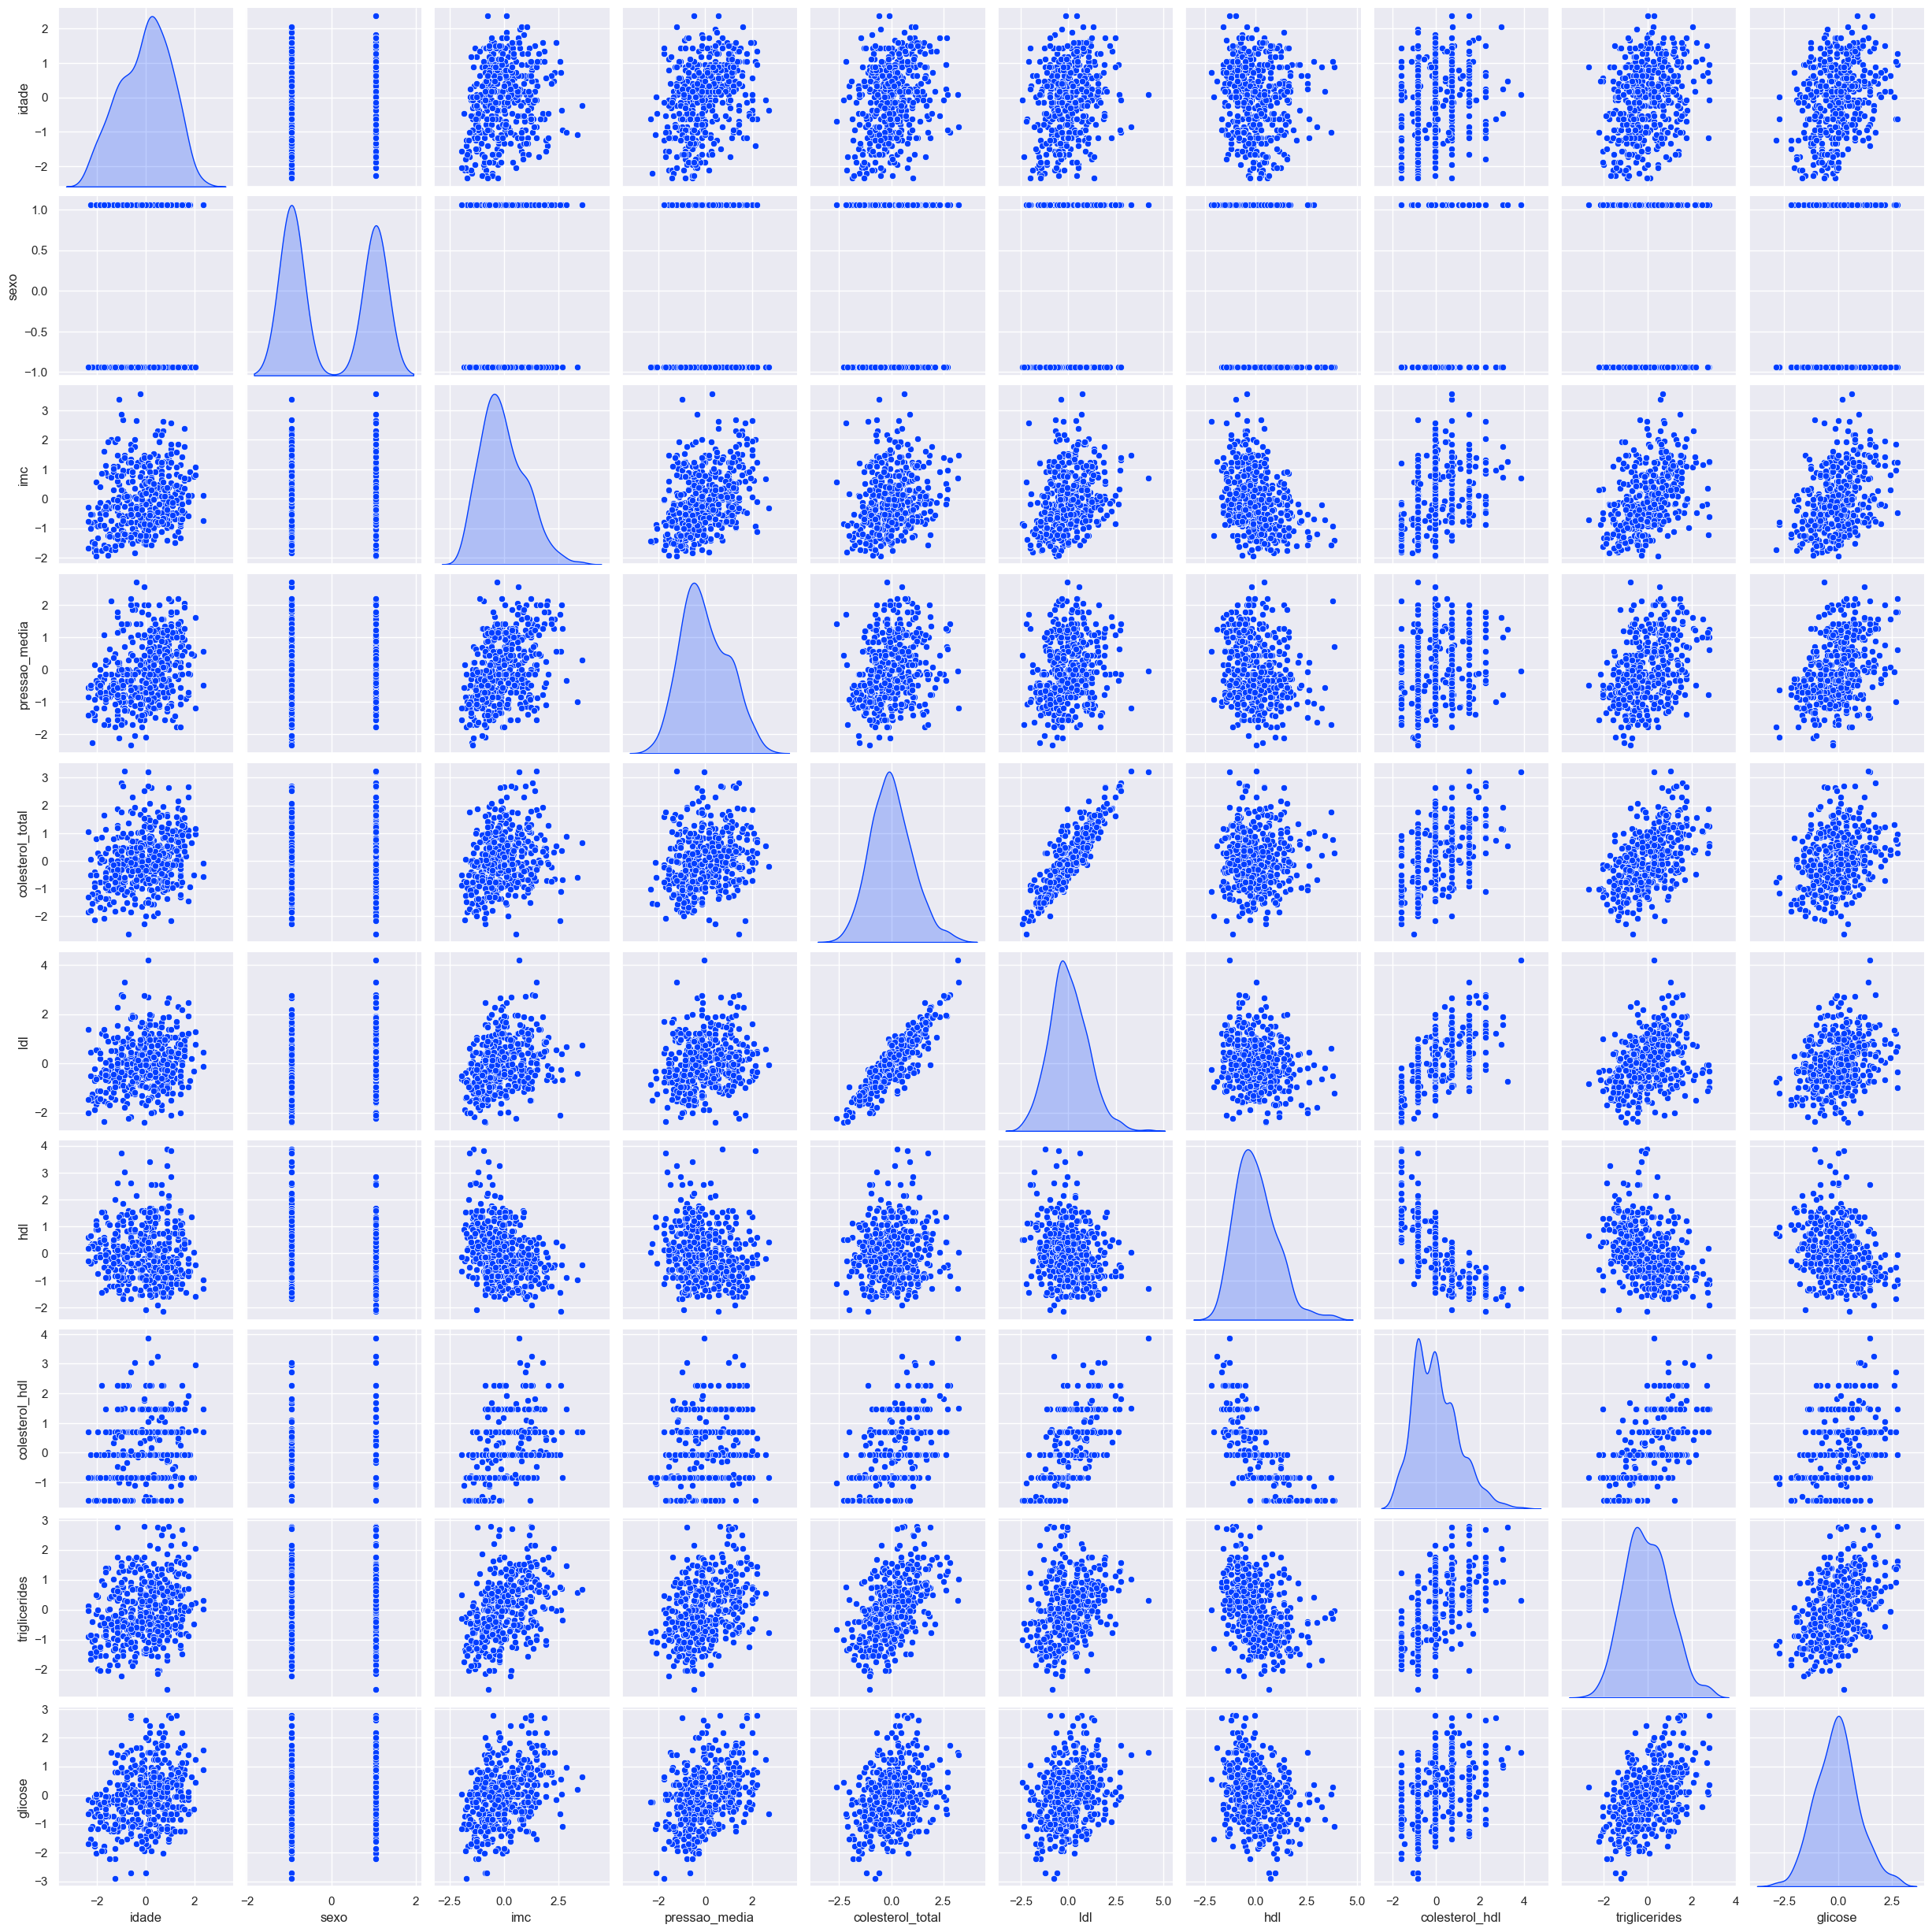

In [17]:
X_scaled = pipeline["scaler"].transform(X)

X_scaled= pd.DataFrame(X_scaled, columns=X.columns)

sns.pairplot(X_scaled, diag_kind='kde')

In [18]:
X_scaled.mean()

idade              -0.031162
sexo               -0.003865
imc                -0.036766
pressao_media      -0.024368
colesterol_total    0.011642
ldl                 0.016946
hdl                 0.021053
colesterol_hdl     -0.007891
triglicerides      -0.025462
glicose            -0.039142
dtype: float32

In [19]:
X_scaled.std()

idade               1.029192
sexo                1.000895
imc                 1.008701
pressao_media       0.983864
colesterol_total    0.997925
ldl                 1.001164
hdl                 1.013668
colesterol_hdl      0.997838
triglicerides       0.997039
glicose             0.985662
dtype: float32

In [21]:
y_pred = pipeline.predict(X_text)


In [22]:
mean_absolute_error(y_test,y_pred)

42.794097900390625

In [ ]:
mean_squared_error(y_test,y_pred)

2900.193359375

In [24]:
root_mean_squared_error(y_test,y_pred)


53.85344314575195

In [25]:
r2_score(y_test,y_pred)

0.4526028037071228

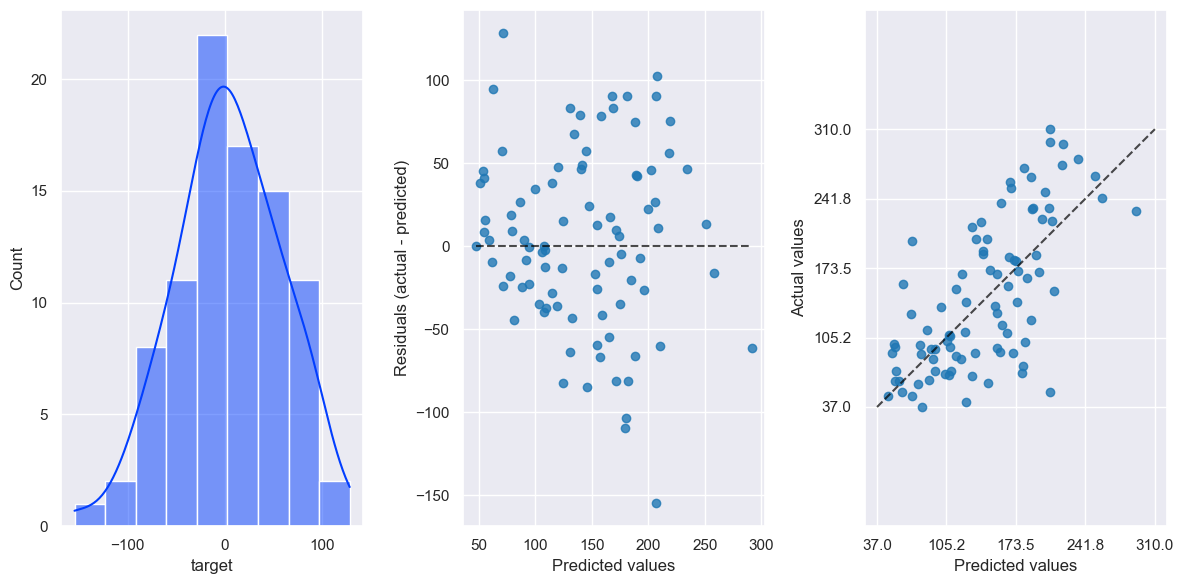

In [26]:
plot_residuos(y_test,y_pred)